In [1]:
import triton
from unsloth import FastLanguageModel

max_seq_length = 4096
load_in_4bit = False 

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Llama-3.2-1B-Instruct",
    max_seq_length = max_seq_length,
    dtype = "float16",
    load_in_4bit = load_in_4bit,
)


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/home/euskov10/TritonInt8Compression/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.4: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.566 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights: 100%|██████████| 146/146 [00:00<00:00, 257.55it/s]
Unsloth: Will load unsloth/Llama-3.2-1B-Instruct as a legacy tokenizer.


In [2]:
model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 2048, padding_idx=128004)
    (layers): ModuleList(
      (0-15): 16 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=512, bias=False)
          (v_proj): Linear(in_features=2048, out_features=512, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)

In [3]:
weights = [
    model.model.layers[0].self_attn.q_proj.weight.to('cuda'),
    model.model.layers[0].self_attn.k_proj.weight.to('cuda'),
    model.model.layers[0].mlp.gate_proj.weight.to('cuda'),
    model.model.layers[0].mlp.down_proj.weight.to('cuda'),
]

In [4]:
for weight in weights:
    print(weight.shape)

torch.Size([2048, 2048])
torch.Size([512, 2048])
torch.Size([8192, 2048])
torch.Size([2048, 8192])


In [ ]:
from kernels.compression_int4 import quant_compress_to_int4 
import torch

import torch.nn as nn

linears = []
for weight in weights:
    linear = nn.Linear(weight.shape[1], weight.shape[0], bias=False, dtype=torch.float16).to('cuda')
    linear.data = weight.data
    linears.append(linear)
    
@torch.no_grad()
def benchmark_quant_gemm(M, quant_block_size, i, provider, provider_funcs):
    weight = weights[i]
    linear = linears[i]
    N, K = weight.shape

    x = torch.randn((M, K), dtype=torch.float16, device='cuda')
    weight_comp8, scale8 = quant_compress_to_int4(weight, compress_factor=8, quant_block_size=quant_block_size)
    weight_comp2, scale2 = quant_compress_to_int4(weight, compress_factor=2, quant_block_size=quant_block_size)

    quantiles = [0.5, 0.2, 0.8]
    ms, min_ms, max_ms = triton.testing.do_bench(
        lambda: provider_funcs[provider](x, weight, weight_comp2, scale2, weight_comp8, scale8, linear), quantiles=quantiles)
    perf = lambda ms: ms # TFlops = 2 * M * N * K * 1e-12 / (ms * 1e-3)
    
    print(f"[Live] M={M:^5} | Quant block size={quant_block_size:^5} | N={N:^5} | K={K:^5} | {provider}: {ms:.4f} ms", flush=True)
    return perf(ms), perf(max_ms), perf(min_ms)

In [6]:
@torch.compile
def matmul_compile(a, b):
    return torch.matmul(a, b.T)

In [7]:
from kernels.decompress_int4_matmul_float16_fused import decompress_int4_matmul_float16_fused



configs = [
    *[
        triton.testing.Benchmark(
            x_names=["M"],  # Argument names to use as an x-axis for the plot
            x_vals=[1, 2, 4],  # Different possible values for `x_name`
            line_arg="provider",  # Argument name whose value corresponds to a different line in the plot
            # Possible values for `line_arg`
            line_vals=["matmul torch", "triton compress 8", "triton compress 2", 'nn.Linear', 'matmul compile'],  # Label name for the lines
            line_names=["Torch", "Triton Uint32", "Triton Uint8", "Linear", "Compile"],  # Line styles
            styles=[("green", "-"), ("blue", "-"), ("red", "-"), ("orange", "-"), ("purple", "-")],
            ylabel="ms",  # Label name for the y-axis
            plot_name="GeMV-performance-" + ("fp16"),  # Name for the plot, used also as a file name for saving the plot.
            args={
                "provider_funcs": {
                    "triton compress 8": lambda a, b, c, d, e, f, l: decompress_int4_matmul_float16_fused(e, f, a), 
                    "triton compress 2": lambda a, b, c, d, e, f, l: decompress_int4_matmul_float16_fused(c, d, a), 
                    "matmul torch": lambda a, b, c, d, e, f, l: torch.matmul(a, b.T),
                    "nn.Linear": lambda a, b, c, d, e, f, l: l(a),
                    "matmul compile": lambda a, b, c, d, e, f, l: matmul_compile(a, b)
                },
                "quant_block_size": 64,
                "i": i,
            },
        )   
        for i in range(len(weights))
    ],
    *[
        triton.testing.Benchmark(
            x_names=["quant_block_size"],  # Argument names to use as an x-axis for the plot
            x_vals=[16, 32, 64, 128],  # Different possible values for `x_name`
            line_arg="provider",  # Argument name whose value corresponds to a different line in the plot
            # Possible values for `line_arg`
            line_vals=["triton compress 8", "triton compress 2"],  # Label name for the lines
            line_names=["Triton Uint32", "Triton Uint8"],  # Line styles
            styles=[("green", "-"), ("blue", "-")],
            ylabel="ms",  # Label name for the y-axis
            plot_name="GeMV-performance-" + ("fp16"),  # Name for the plot, used also as a file name for saving the plot.
            args={
                "provider_funcs": {
                    "triton compress 8": lambda a, b, c, d, e, f, l: decompress_int4_matmul_float16_fused(e, f, a), 
                    "triton compress 2": lambda a, b, c, d, e, f, l: decompress_int4_matmul_float16_fused(c, d, a), 
                },
                "M": 1,
                "i": i,
            },
        )
        for i in range(len(weights))
    ]
]

[Live] M=  1   | Quant block size= 64   | N=2048  | K=2048  | matmul torch: 0.0540 ms
[Live] M=  1   | Quant block size= 64   | N=2048  | K=2048  | triton compress 8: 0.0547 ms
[Live] M=  1   | Quant block size= 64   | N=2048  | K=2048  | triton compress 2: 0.0348 ms
[Live] M=  1   | Quant block size= 64   | N=2048  | K=2048  | nn.Linear: 0.0431 ms
[Live] M=  1   | Quant block size= 64   | N=2048  | K=2048  | matmul compile: 0.0413 ms
[Live] M=  2   | Quant block size= 64   | N=2048  | K=2048  | matmul torch: 0.0570 ms
[Live] M=  2   | Quant block size= 64   | N=2048  | K=2048  | triton compress 8: 0.0471 ms
[Live] M=  2   | Quant block size= 64   | N=2048  | K=2048  | triton compress 2: 0.0320 ms
[Live] M=  2   | Quant block size= 64   | N=2048  | K=2048  | nn.Linear: 0.0569 ms
[Live] M=  2   | Quant block size= 64   | N=2048  | K=2048  | matmul compile: 0.0571 ms
[Live] M=  4   | Quant block size= 64   | N=2048  | K=2048  | matmul torch: 0.0572 ms
[Live] M=  4   | Quant block size= 6

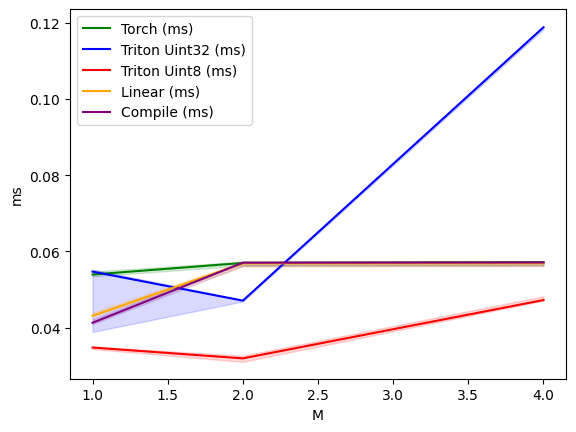

GeMV-performance-fp16:
     M  Torch (ms)  Triton Uint32 (ms)  Triton Uint8 (ms)  Linear (ms)  Compile (ms)
0  1.0    0.053952            0.054720           0.034816     0.043136      0.041312
1  2.0    0.056992            0.047104           0.031968     0.056864      0.057056
2  4.0    0.057184            0.118784           0.047264     0.056896      0.057120
[Live] M=  1   | Quant block size= 64   | N= 512  | K=2048  | matmul torch: 0.0159 ms
[Live] M=  1   | Quant block size= 64   | N= 512  | K=2048  | triton compress 8: 0.0266 ms
[Live] M=  1   | Quant block size= 64   | N= 512  | K=2048  | triton compress 2: 0.0248 ms
[Live] M=  1   | Quant block size= 64   | N= 512  | K=2048  | nn.Linear: 0.0157 ms
[Live] M=  1   | Quant block size= 64   | N= 512  | K=2048  | matmul compile: 0.0158 ms
[Live] M=  2   | Quant block size= 64   | N= 512  | K=2048  | matmul torch: 0.0183 ms
[Live] M=  2   | Quant block size= 64   | N= 512  | K=2048  | triton compress 8: 0.0272 ms
[Live] M=  2   | Quan

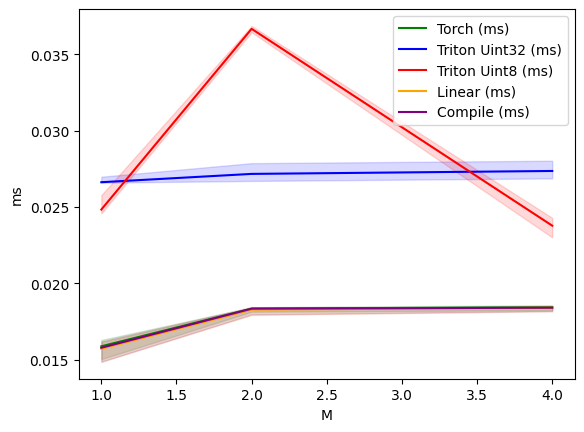

GeMV-performance-fp16:
     M  Torch (ms)  Triton Uint32 (ms)  Triton Uint8 (ms)  Linear (ms)  Compile (ms)
0  1.0    0.015872            0.026624           0.024832     0.015712      0.015776
1  2.0    0.018336            0.027168           0.036672     0.018272      0.018336
2  4.0    0.018432            0.027360           0.023776     0.018400      0.018400
[Live] M=  1   | Quant block size= 64   | N=8192  | K=2048  | matmul torch: 0.1418 ms
[Live] M=  1   | Quant block size= 64   | N=8192  | K=2048  | triton compress 8: 0.1106 ms
[Live] M=  1   | Quant block size= 64   | N=8192  | K=2048  | triton compress 2: 0.0960 ms
[Live] M=  1   | Quant block size= 64   | N=8192  | K=2048  | nn.Linear: 0.1411 ms
[Live] M=  1   | Quant block size= 64   | N=8192  | K=2048  | matmul compile: 0.1416 ms
[Live] M=  2   | Quant block size= 64   | N=8192  | K=2048  | matmul torch: 0.1542 ms
[Live] M=  2   | Quant block size= 64   | N=8192  | K=2048  | triton compress 8: 0.1825 ms
[Live] M=  2   | Quan

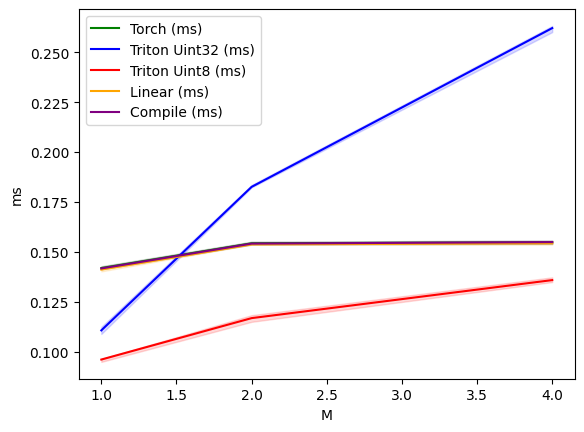

GeMV-performance-fp16:
     M  Torch (ms)  Triton Uint32 (ms)  Triton Uint8 (ms)  Linear (ms)  Compile (ms)
0  1.0    0.141824            0.110592           0.095968     0.141056      0.141632
1  2.0    0.154240            0.182528           0.116736     0.153664      0.154080
2  4.0    0.154720            0.262112           0.135792     0.154272      0.154848
[Live] M=  1   | Quant block size= 64   | N=2048  | K=8192  | matmul torch: 0.1483 ms
[Live] M=  1   | Quant block size= 64   | N=2048  | K=8192  | triton compress 8: 0.1469 ms
[Live] M=  1   | Quant block size= 64   | N=2048  | K=8192  | triton compress 2: 0.1564 ms
[Live] M=  1   | Quant block size= 64   | N=2048  | K=8192  | nn.Linear: 0.1481 ms
[Live] M=  1   | Quant block size= 64   | N=2048  | K=8192  | matmul compile: 0.1485 ms
[Live] M=  2   | Quant block size= 64   | N=2048  | K=8192  | matmul torch: 0.1559 ms


In [ ]:
triton.testing.perf_report(configs)(benchmark_quant_gemm).run(show_plots=True, print_data=True)